In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline

import joblib

In [2]:
DATA_PATH = "../data/processed/cleaned_support_tickets.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (26872, 11)


,ticket_id,instruction,instruction_clean,category,intent,response,flags,instruction_word_count,instruction_char_count,response_word_count,split
0,TICKET_00001,question about cancelling order {{Order Number}},question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...,B,6,48,37,train
1,TICKET_00002,i have a question about cancelling oorder {{Or...,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...,BQZ,9,58,48,test
2,TICKET_00003,i need help cancelling puchase {{Order Number}},i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...,BLQZ,7,47,205,train
3,TICKET_00004,I need to cancel purchase {{Order Number}},I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...,BL,7,42,166,train
4,TICKET_00005,"I cannot afford this order, cancel purchase {{...","I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...,BCELN,9,60,191,test


In [3]:
df["split"].value_counts()

split
train         18840
validation     4019
test           4013
Name: count, dtype: int64

In [4]:
required_columns = [
    "ticket_id",
    "instruction",
    "instruction_clean",
    "intent",
    "category",
    "split"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing columns:", missing_columns)

assert len(missing_columns) == 0, (
    f"Missing columns: {missing_columns}"
)

Missing columns: []


In [5]:
train_df = df[df["split"] == "train"].copy()
validation_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print("Train rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Test rows:", len(test_df))

Train rows: 18840
Validation rows: 4019
Test rows: 4013


In [6]:
X_train = train_df["instruction_clean"]
y_train = train_df["intent"]

X_val = validation_df["instruction_clean"]
y_val = validation_df["intent"]

X_test = test_df["instruction_clean"]
y_test = test_df["intent"]

In [7]:
print("Train intents:", y_train.nunique())
print("Validation intents:", y_val.nunique())
print("Test intents:", y_test.nunique())

Train intents: 27
Validation intents: 27
Test intents: 27


In [8]:
assert set(y_val.unique()).issubset(set(y_train.unique()))
assert set(y_test.unique()).issubset(set(y_train.unique()))

print("All validation/test labels exist in training data.")

All validation/test labels exist in training data.


In [9]:
dummy_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000
        )
    ),
    (
        "classifier",
        DummyClassifier(
            strategy="most_frequent"
        )
    )
])

In [10]:
dummy_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](27,)","['cancel_order','change_order','change_shipping_address',..., 'switch_account','track_order','track_refund']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


In [11]:
dummy_val_predictions = dummy_model.predict(X_val)

In [12]:
dummy_accuracy = accuracy_score(
    y_val,
    dummy_val_predictions
)

dummy_precision, dummy_recall, dummy_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        dummy_val_predictions,
        average="macro",
        zero_division=0
    )
)

print("DUMMY BASELINE — VALIDATION")
print("=" * 50)

print(f"Accuracy:        {dummy_accuracy:.4f}")
print(f"Macro Precision: {dummy_precision:.4f}")
print(f"Macro Recall:    {dummy_recall:.4f}")
print(f"Macro F1-score:  {dummy_f1:.4f}")

DUMMY BASELINE — VALIDATION
Accuracy:        0.0336
Macro Precision: 0.0012
Macro Recall:    0.0370
Macro F1-score:  0.0024


In [13]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [14]:
baseline_model.fit(
    X_train,
    y_train
)

print("TF-IDF + Logistic Regression training complete.")

TF-IDF + Logistic Regression training complete.


In [15]:
val_predictions = baseline_model.predict(X_val)

print("Validation predictions generated.")

Validation predictions generated.


In [16]:
val_accuracy = accuracy_score(
    y_val,
    val_predictions
)

val_precision, val_recall, val_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        val_predictions,
        average="macro",
        zero_division=0
    )
)

print("TF-IDF + LOGISTIC REGRESSION — VALIDATION")
print("=" * 55)

print(f"Accuracy:        {val_accuracy:.4f}")
print(f"Macro Precision: {val_precision:.4f}")
print(f"Macro Recall:    {val_recall:.4f}")
print(f"Macro F1-score:  {val_f1:.4f}")

TF-IDF + LOGISTIC REGRESSION — VALIDATION
Accuracy:        0.9940
Macro Precision: 0.9940
Macro Recall:    0.9941
Macro F1-score:  0.9940


In [17]:
comparison_df = pd.DataFrame({
    "Model": [
        "Dummy - Most Frequent",
        "TF-IDF + Logistic Regression"
    ],
    "Accuracy": [
        dummy_accuracy,
        val_accuracy
    ],
    "Macro Precision": [
        dummy_precision,
        val_precision
    ],
    "Macro Recall": [
        dummy_recall,
        val_recall
    ],
    "Macro F1": [
        dummy_f1,
        val_f1
    ]
})

comparison_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Dummy - Most Frequent,0.0336,0.0012,0.0370,0.0024
1,TF-IDF + Logistic Regression,0.9940,0.9940,0.9941,0.9940


In [18]:
validation_report = classification_report(
    y_val,
    val_predictions,
    zero_division=0
)

print(validation_report)

                          precision    recall  f1-score   support

            cancel_order       0.99      0.97      0.98       152
            change_order       0.97      0.97      0.97       148
 change_shipping_address       1.00      1.00      1.00       146
  check_cancellation_fee       1.00      1.00      1.00       142
           check_invoice       0.99      1.00      0.99       148
   check_payment_methods       1.00      1.00      1.00       150
     check_refund_policy       1.00      1.00      1.00       149
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.99      1.00       150
     contact_human_agent       0.99      0.99      0.99       150
          create_account       0.99      0.98      0.98       149
          delete_account       0.99      1.00      0.99       153
        delivery_options       0.99      1.00      1.00       135
         delivery_period       0.99      1.00      1.00       150
         

In [19]:
validation_report_dict = classification_report(
    y_val,
    val_predictions,
    output_dict=True,
    zero_division=0
)

validation_report_df = pd.DataFrame(
    validation_report_dict
).transpose()

validation_report_df.round(4)

,precision,recall,f1-score,support
cancel_order,0.9932,0.9671,0.9800,152.000
change_order,0.9664,0.9730,0.9697,148.000
change_shipping_address,1.0000,1.0000,1.0000,146.000
check_cancellation_fee,1.0000,1.0000,1.0000,142.000
check_invoice,0.9867,1.0000,0.9933,148.000
check_payment_methods,1.0000,1.0000,1.0000,150.000
check_refund_policy,1.0000,1.0000,1.0000,149.000
complaint,1.0000,1.0000,1.0000,150.000
contact_customer_service,1.0000,0.9933,0.9967,150.000
contact_human_agent,0.9933,0.9933,0.9933,150.000


In [20]:
intent_performance = (
    validation_report_df
    .loc[y_val.unique()]
    .sort_values("f1-score")
)

intent_performance[
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].head(10)

,precision,recall,f1-score,support
change_order,0.966443,0.972973,0.969697,148.0
cancel_order,0.993243,0.967105,0.980000,152.0
create_account,0.986486,0.979866,0.983165,149.0
registration_problems,0.980132,0.986667,0.983389,150.0
place_order,0.986667,0.993289,0.989967,149.0
get_refund,0.987097,0.993506,0.990291,154.0
edit_account,0.985816,1.000000,0.992857,139.0
set_up_shipping_address,1.000000,0.986577,0.993243,149.0
check_invoice,0.986667,1.000000,0.993289,148.0
get_invoice,1.000000,0.986667,0.993289,150.0


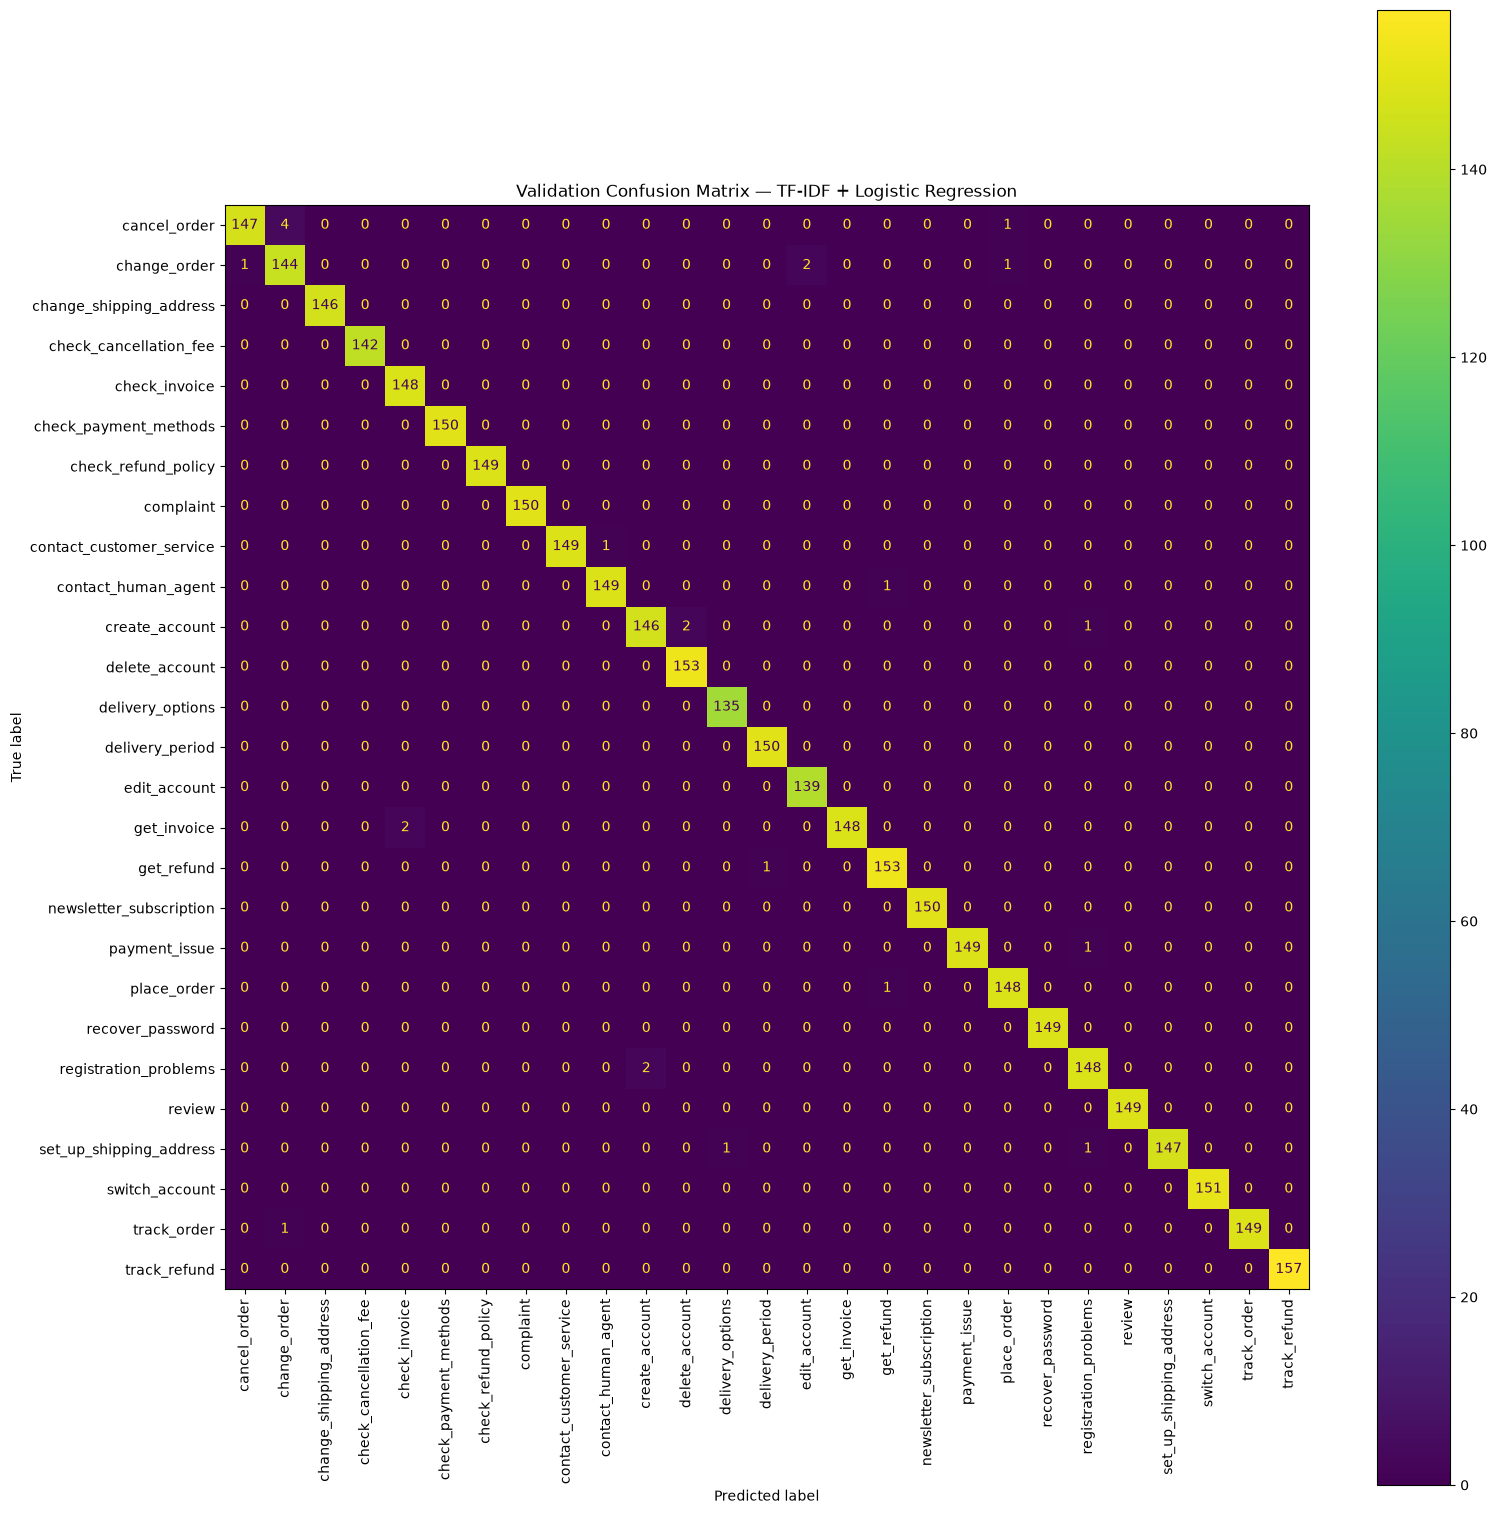

In [21]:
labels = sorted(y_val.unique())

cm = confusion_matrix(
    y_val,
    val_predictions,
    labels=labels
)

fig, ax = plt.subplots(figsize=(16, 16))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "Validation Confusion Matrix — TF-IDF + Logistic Regression"
)

plt.tight_layout()
plt.show()

In [22]:
validation_results = validation_df[
    [
        "ticket_id",
        "instruction",
        "category",
        "intent"
    ]
].copy()

validation_results["predicted_intent"] = val_predictions

validation_results["correct"] = (
    validation_results["intent"]
    ==
    validation_results["predicted_intent"]
)

In [23]:
validation_results["correct"].mean()

np.float64(0.9940283652649913)

In [24]:
errors_df = validation_results[
    validation_results["correct"] == False
].copy()

print("Incorrect predictions:", len(errors_df))

errors_df.sample(
    min(20, len(errors_df)),
    random_state=42
)

Incorrect predictions: 24


,ticket_id,instruction,category,intent,predicted_intent,correct
1712,TICKET_01713,modify order00123842,ORDER,change_order,edit_account,False
15925,TICKET_15926,when can I expect a refund,REFUND,get_refund,delivery_period,False
265,TICKET_00266,can you help me cancelong purchase {{Order Num...,ORDER,cancel_order,change_order,False
19665,TICKET_19666,makepurchase,ORDER,place_order,get_refund,False
10231,TICKET_10232,register,ACCOUNT,create_account,registration_problems,False
8438,TICKET_08439,I don't know what to do to speak with cusstome...,CONTACT,contact_customer_service,contact_human_agent,False
10561,TICKET_10562,help me creting a {{Account Type}} account,ACCOUNT,create_account,delete_account,False
317,TICKET_00318,I want assistance to cancle purchase {{Order N...,ORDER,cancel_order,change_order,False
23556,TICKET_23557,deliveryaddress issue,SHIPPING,set_up_shipping_address,registration_problems,False
1080,TICKET_01081,need to change several products of purchase113...,ORDER,change_order,place_order,False


In [25]:
confusion_pairs = (
    errors_df
    .groupby(
        [
            "intent",
            "predicted_intent"
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

confusion_pairs.head(15)

,intent,predicted_intent,count
0,cancel_order,change_order,4
3,change_order,edit_account,2
7,create_account,delete_account,2
13,registration_problems,create_account,2
9,get_invoice,check_invoice,2
4,change_order,place_order,1
5,contact_customer_service,contact_human_agent,1
2,change_order,cancel_order,1
1,cancel_order,place_order,1
8,create_account,registration_problems,1


In [26]:
for _, row in errors_df.head(10).iterrows():

    print("=" * 80)

    print("CUSTOMER:")
    print(row["instruction"])

    print("\nEXPECTED:")
    print(row["intent"])

    print("\nPREDICTED:")
    print(row["predicted_intent"])

CUSTOMER:
can you help me cancelong purchase {{Order Number}}?

EXPECTED:
cancel_order

PREDICTED:
change_order
CUSTOMER:
I want assistance to cancle purchase {{Order Number}}

EXPECTED:
cancel_order

PREDICTED:
change_order
CUSTOMER:
can you help me camceling the purchase I made?

EXPECTED:
cancel_order

PREDICTED:
place_order
CUSTOMER:
question about cancellung purchase {{Order Number}}

EXPECTED:
cancel_order

PREDICTED:
change_order
CUSTOMER:
I want assistance to cancle purchase {{Order Number}}

EXPECTED:
cancel_order

PREDICTED:
change_order
CUSTOMER:
need to change several products of purchase113542617735902

EXPECTED:
change_order

PREDICTED:
place_order
CUSTOMER:
update purchase00123842

EXPECTED:
change_order

PREDICTED:
edit_account
CUSTOMER:
assistance with hcanging order {{Order Number}}

EXPECTED:
change_order

PREDICTED:
cancel_order
CUSTOMER:
modify order00123842

EXPECTED:
change_order

PREDICTED:
edit_account
CUSTOMER:
I don't know what to do to speak with cusstomer s

In [27]:
candidate_c_values = [
    0.5,
    1.0,
    2.0
]

tuning_results = []

In [28]:
for c_value in candidate_c_values:

    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=30000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                C=c_value,
                max_iter=1000,
                random_state=42
            )
        )
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    _, _, macro_f1, _ = (
        precision_recall_fscore_support(
            y_val,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    tuning_results.append({
        "C": c_value,
        "Validation Accuracy": accuracy,
        "Validation Macro F1": macro_f1
    })

In [29]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values(
    "Validation Macro F1",
    ascending=False
)

,C,Validation Accuracy,Validation Macro F1
2,2.0,0.994028,0.994038
1,1.0,0.994028,0.994036
0,0.5,0.990047,0.990045


In [30]:
best_c = (
    tuning_df
    .sort_values(
        "Validation Macro F1",
        ascending=False
    )
    .iloc[0]["C"]
)

print("Best C:", best_c)

Best C: 2.0


In [31]:
train_val_df = pd.concat(
    [
        train_df,
        validation_df
    ],
    ignore_index=True
)

X_train_val = train_val_df["instruction_clean"]
y_train_val = train_val_df["intent"]

In [32]:
final_baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            C=float(best_c),
            max_iter=1000,
            random_state=42
        )
    )
])

In [33]:
final_baseline_model.fit(
    X_train_val,
    y_train_val
)

print("Final baseline model trained.")

Final baseline model trained.


In [34]:
test_predictions = final_baseline_model.predict(
    X_test
)

In [35]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

print("FINAL TEST RESULTS")
print("=" * 50)

print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1-score:  {test_f1:.4f}")

FINAL TEST RESULTS
Accuracy:        0.9923
Macro Precision: 0.9926
Macro Recall:    0.9922
Macro F1-score:  0.9923


In [36]:
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

                          precision    recall  f1-score   support

            cancel_order       0.99      0.99      0.99       138
            change_order       0.98      0.98      0.98       164
 change_shipping_address       0.99      1.00      1.00       146
  check_cancellation_fee       0.99      1.00      1.00       143
           check_invoice       0.95      1.00      0.97       159
   check_payment_methods       1.00      1.00      1.00       150
     check_refund_policy       1.00      0.99      1.00       150
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.98      0.99       150
     contact_human_agent       0.98      1.00      0.99       150
          create_account       1.00      0.98      0.99       150
          delete_account       0.97      0.99      0.98       145
        delivery_options       1.00      1.00      1.00       148
         delivery_period       1.00      1.00      1.00       150
         

In [37]:
test_results = test_df[
    [
        "ticket_id",
        "instruction",
        "category",
        "intent"
    ]
].copy()

test_results["predicted_intent"] = test_predictions

test_results["correct"] = (
    test_results["intent"]
    ==
    test_results["predicted_intent"]
)

test_results.head()

,ticket_id,instruction,category,intent,predicted_intent,correct
1,TICKET_00002,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,cancel_order,True
4,TICKET_00005,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,cancel_order,True
13,TICKET_00014,can you help me canceling order {{Order Number}}?,ORDER,cancel_order,cancel_order,True
14,TICKET_00015,help me canceling purchase {{Order Number}},ORDER,cancel_order,cancel_order,True
20,TICKET_00021,I'm trying to cancel order {{Order Number}},ORDER,cancel_order,cancel_order,True


In [38]:
TEST_RESULTS_PATH = (
    "../evaluation/baseline_test_results.csv"
)

test_results.to_csv(
    TEST_RESULTS_PATH,
    index=False
)

print(
    f"Test results saved to: "
    f"{TEST_RESULTS_PATH}"
)

Test results saved to: ../evaluation/baseline_test_results.csv


In [39]:
MODEL_PATH = (
    "../models/tfidf_logistic_regression_intent.joblib"
)

joblib.dump(
    final_baseline_model,
    MODEL_PATH
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: ../models/tfidf_logistic_regression_intent.joblib


In [40]:
loaded_model = joblib.load(
    "../models/tfidf_logistic_regression_intent.joblib"
)

In [41]:
example_message = [
    "I returned my order but I still have not received my money back."
]

prediction = loaded_model.predict(
    example_message
)

print(
    "Predicted intent:",
    prediction[0]
)

Predicted intent: get_refund


In [42]:
example_message = [
    "Please cancel my order before it is shipped."
]

prediction = loaded_model.predict(
    example_message
)

print(
    "Predicted intent:",
    prediction[0]
)

Predicted intent: cancel_order


In [43]:
baseline_metrics = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "task": "intent_classification",
        "accuracy": test_accuracy,
        "macro_precision": test_precision,
        "macro_recall": test_recall,
        "macro_f1": test_f1
    }
])

baseline_metrics

,model,task,accuracy,macro_precision,macro_recall,macro_f1
0,TF-IDF + Logistic Regression,intent_classification,0.992275,0.992628,0.992212,0.992325


In [44]:
baseline_metrics.to_csv(
    "../evaluation/baseline_metrics.csv",
    index=False
)